# Pulse arrival times from the Crab pulsar
## Crab Pulsar Experiment Part 3.2

Use this notebook as a template for Part 3.2 of the Crab pulsar experiment.

In [1]:
# To begin, we import some libraries that we will need later.

# Some handy standard python libraries
import os

# The numpy library is very useful for many things
import numpy as np

# The interpolate library from scipy includes powerful interpolation routines
# including the Lagrange interpolation described in the lab script.
from scipy import interpolate

# Astropy provides many useful tools...
from astropy import coordinates as coord
from astropy import units as u
from astropy import constants as const
from astropy import time as astrotime

# The pyplot module from matplotlib will allow us to plot things.
from matplotlib import pyplot as plt
from math import pi

## Load Data
Here we load your ToA data as well as the file containing solar system barycentre coordinates.

In [3]:
import numpy as np

filepath = "/Users/alismk/Desktop/3rdYear Courses/Sem2/Lab/Obs/20260217_143556_B0531+21.npz"

data = np.load(filepath, allow_pickle=True)

print(data.files)   # shows what's inside the npz
print(data['times'])

['times', 'freqs', 'cfreq', 'bw', 'data', 'approx_period', 'header', 'source_name']
[61088.6096061  61088.61180509 61088.61412005 61088.61643463
 61088.6187496  61088.62106456 61088.62337914 61088.62569411
 61088.62800907 61088.63032404 61088.63263901 61088.63491518
 61088.63726816 61088.63958312 61088.64188477 61088.64421306
 61088.64652724 61088.64884221 61088.65208348 61088.65347214
 61088.65578672 61088.65810169 61088.66041626 61088.66273162
 61088.6650458  61088.66736077 61088.66961775 61088.67199031
 61088.67430528 61088.67658146 61088.67910841 61088.68124979
 61088.68356437 61088.68587934 61088.68819391 61088.69050888]


In [5]:
import os
import numpy as np

basepath = "/Users/alismk/Desktop/3rdYear Courses/Sem2/Lab/Obs"

npzfile  = os.path.join(basepath, "20260217_143556_B0531+21.npz")
baryfile = os.path.join(basepath, "ssb_2022.txt")

# Load barycentre file (text)
year, month, day, xpos, ypos, zpos = np.loadtxt(baryfile, unpack=True)

# Load pulsar observation (binary npz)
obs = np.load(npzfile, allow_pickle=True)

print("Loaded npz keys:", obs.files)
print("source_name:", obs["source_name"])
print("approx_period:", obs["approx_period"])
print("data shape:", obs["data"].shape)

Loaded npz keys: ['times', 'freqs', 'cfreq', 'bw', 'data', 'approx_period', 'header', 'source_name']
source_name: B0531+21
approx_period: 0.03385139
data shape: (36, 40, 1024)


## Interpolation
The Earth-barycentre vector is only given once per day (at 0 UT) in your input file. Therefore you will need to [interpolate](https://en.wikipedia.org/wiki/Interpolation) to get the vector at the time of each of your ToAs.

The below is an example code showing interpolation of a simple sinusoid function. Make sure you understand what this code is doing, then replace it with a function to interpolate your x, y and z positions at the times of your ToAs.

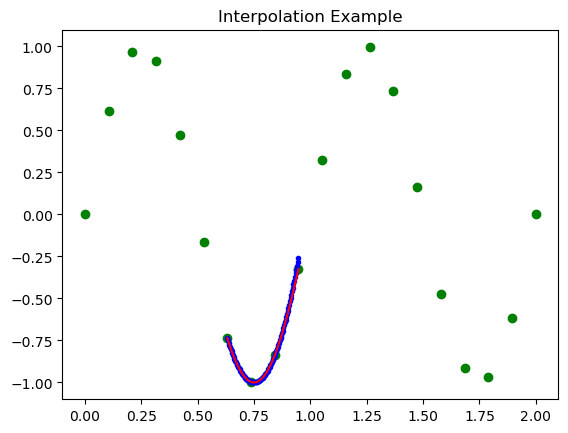

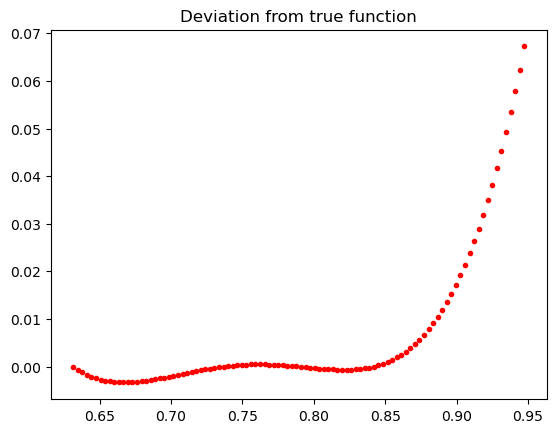

In [6]:
# Interpolation example, interpolating part of a sine function.

# This is the X and Y data points of the sine function
x = np.linspace(start=0,stop=2,num=20)
y = np.sin(2*pi*x)

# We will interpolate using
start_point = 6
interp_number=3

interp_function = interpolate.lagrange(x[start_point:start_point+interp_number],\
                                       y[start_point:start_point+interp_number])

x2 = np.linspace(x[start_point],x[start_point+interp_number],100)
y2 = interp_function(x2)

y3 = np.sin(2*pi*x2)

plt.plot(x,y,'o',color='green')
plt.plot(x2,y2,'.',color='blue')
plt.plot(x2,y3,'-',color='red')
plt.ylim(-1.1,1.1)
plt.title("Interpolation Example")
plt.figure()
plt.plot(x2,y2-y3,'.',color='red')
plt.title("Deviation from true function")
plt.show()


## Compute the Earth delay

This is the delay due to the fact that the observatory is not at the centre of the Earth. For this, you need to know the elevation angle above the horizon (see the lab script for more details).

The [Astropy](http://www.astropy.org/) library provides very powerful tools to do things like coordinate transforms. Here we want to convert from equitorial (RA and Dec) coordinate system to an observatory-based [AltAz](http://docs.astropy.org/en/stable/api/astropy.coordinates.AltAz.html) coordinate system. Make sure you are familiar with these two coordinate systems. The conversion from one to the other requries knowing the location of your telecsope and also the time the observations were taken.

The following libraries have been imported for your convinience:
 * ``astropy.coordinate`` has been imported as ``coord``
 * ``astropy.time`` has been imported as ``astrotime``
 

In [7]:
# Insert the position of the crab pulsar here!
pulsarpos = coord.SkyCoord(ra="01:23:45.6",dec="12:34:56.7",unit=(u.hourangle,u.deg))

#lovellpos = coord.EarthLocation(...)

#times = astrotime.Time(...)

# To compute the angle between the pulsar and the earth we can use astropy to tell us the elevation angle to the pulsar.
# First Transform the coordinate system to an Alt-Az system. This needs the location of the telescope and the times
# of the observation.
# altaz = pulsarpos.transform_to(coord.AltAz(obstime=times,location=lovellpos))


# earth_delay = ...

## Compute the Roemer delay

This is the delay corresponding to the distance of the centre of the Earth to the barycentre.


In [8]:


# psr_x = ...
# psr_y = ...
# psr_z = ...

# roemer_delay = ...

## Residuals from a fixed period model



In [9]:
# The data file includes a sutiable 'guess period' as described in the lab script.
# You can either load the data file or get it from the 'Make Time of Arrivals' notebook.
period_guess = ...


# residual = 

# Do fitting (try the polyfit routine in numpy)

In [10]:
import os
import numpy as np

basepath = "/Users/alismk/Desktop/3rdYear Courses/Sem2/Lab/Obs"

npzfile  = os.path.join(basepath, "20260217_143556_B0531+21.npz")
baryfile = os.path.join(basepath, "ssb_2022.txt")

obs = np.load(npzfile, allow_pickle=True)
times_mjd = np.array(obs["times"], dtype=float)   # these are your "ToA-like" times for interpolation

year, month, day, xpos, ypos, zpos = np.loadtxt(baryfile, unpack=True)
year = year.astype(int); month = month.astype(int); day = day.astype(int)

In [11]:
def ymd_to_mjd(y, m, d):
    """
    Convert Gregorian calendar date (year,month,day) at 0 UT to MJD.
    Works for modern dates (post-1900 etc).
    """
    y = np.array(y, dtype=int)
    m = np.array(m, dtype=int)
    d = np.array(d, dtype=int)

    a = (14 - m) // 12
    y2 = y + 4800 - a
    m2 = m + 12*a - 3

    # Julian Day Number (integer JD at 0 UT)
    jdn = d + ((153*m2 + 2)//5) + 365*y2 + (y2//4) - (y2//100) + (y2//400) - 32045

    # JD at 0 UT is jdn - 0.5; MJD = JD - 2400000.5
    mjd = (jdn - 0.5) - 2400000.5
    return mjd

bary_mjd = ymd_to_mjd(year, month, day)

In [12]:
print("bary MJD range:", bary_mjd.min(), "to", bary_mjd.max())
print("your times range:", times_mjd.min(), "to", times_mjd.max())

bary MJD range: 59580.0 to 59944.0
your times range: 61088.60960610387 to 61088.69050887886


In [13]:
def lagrange_eval(x_nodes, y_nodes, xq):
    """
    Evaluate Lagrange interpolating polynomial through (x_nodes, y_nodes) at xq.
    x_nodes: (k,)
    y_nodes: (k,)
    xq: scalar
    """
    x_nodes = np.asarray(x_nodes, dtype=float)
    y_nodes = np.asarray(y_nodes, dtype=float)
    k = len(x_nodes)

    total = 0.0
    for i in range(k):
        xi = x_nodes[i]
        li = 1.0
        for j in range(k):
            if j == i:
                continue
            li *= (xq - x_nodes[j]) / (xi - x_nodes[j])
        total += y_nodes[i] * li
    return total

In [14]:
def interpolate_xyz(times_mjd, bary_mjd, xpos, ypos, zpos, k=4):
    """
    Interpolate barycentre x,y,z at each time in times_mjd using k-point Lagrange interpolation.
    k=4 or k=5 are usually good. (k=3 also works but is less accurate.)
    """
    times_mjd = np.asarray(times_mjd, dtype=float)
    bary_mjd = np.asarray(bary_mjd, dtype=float)

    x_out = np.empty_like(times_mjd)
    y_out = np.empty_like(times_mjd)
    z_out = np.empty_like(times_mjd)

    n = len(bary_mjd)
    if n < k:
        raise ValueError(f"Need at least k={k} barycentre rows, only have {n}")

    for idx, t in enumerate(times_mjd):
        # find insertion point
        j = np.searchsorted(bary_mjd, t)

        # choose a window of k points around t
        start = j - (k // 2)
        start = max(0, min(start, n - k))

        xs = bary_mjd[start:start+k]
        x_out[idx] = lagrange_eval(xs, xpos[start:start+k], t)
        y_out[idx] = lagrange_eval(xs, ypos[start:start+k], t)
        z_out[idx] = lagrange_eval(xs, zpos[start:start+k], t)

    return x_out, y_out, z_out

In [15]:
x_i, y_i, z_i = interpolate_xyz(times_mjd, bary_mjd, xpos, ypos, zpos, k=4)

print("First 3 interpolated x,y,z:")
for i in range(min(3, len(times_mjd))):
    print(times_mjd[i], x_i[i], y_i[i], z_i[i])

First 3 interpolated x,y,z:
61088.60960610387 1349.2235806956887 63.0782775580883 34.94367654621601
61088.6118050873 1349.2313718423247 63.07899555563927 34.94403159618378
61088.61412005418 1349.2395739927888 63.079751282930374 34.94440533220768


In [16]:
print(obs["times"])
print(obs["times"].shape)

[61088.6096061  61088.61180509 61088.61412005 61088.61643463
 61088.6187496  61088.62106456 61088.62337914 61088.62569411
 61088.62800907 61088.63032404 61088.63263901 61088.63491518
 61088.63726816 61088.63958312 61088.64188477 61088.64421306
 61088.64652724 61088.64884221 61088.65208348 61088.65347214
 61088.65578672 61088.65810169 61088.66041626 61088.66273162
 61088.6650458  61088.66736077 61088.66961775 61088.67199031
 61088.67430528 61088.67658146 61088.67910841 61088.68124979
 61088.68356437 61088.68587934 61088.68819391 61088.69050888]
(36,)


In [17]:
import numpy as np
from astropy import coordinates as coord
from astropy import units as u
from astropy import time as astrotime

# Pulsar position: PSR B0329+54
pulsarpos = coord.SkyCoord(
    ra="03:32:59.37",
    dec="+54:34:43.57",
    unit=(u.hourangle, u.deg)
)

# 42-ft telescope position (JBO)
telescope_pos = coord.EarthLocation(
    lat=53.23625*u.deg,
    lon=-2.30714*u.deg,
    height=75*u.m
)

# Observation times (MJD)
times = astrotime.Time(times_mjd, format="mjd")

# Alt/Az of pulsar at those times
altaz = pulsarpos.transform_to(coord.AltAz(obstime=times, location=telescope_pos))

# --- Earth delay using the LAB formula: r*sin(eps)/c ---
R_earth = 6371000.0  # meters (Earth radius)
c = 299792458.0      # m/s

earth_delay_sec = (R_earth * np.sin(altaz.alt.to_value(u.rad))) / c

print("Earth delay (seconds):")
print(earth_delay_sec)

Earth delay (seconds):
[0.0187143  0.01879075 0.01887021 0.0189486  0.01902593 0.01910217
 0.01917728 0.01925129 0.01932415 0.01939585 0.01946639 0.01953458
 0.01960386 0.01967079 0.01973612 0.01980095 0.01986413 0.01992606
 0.02001062 0.02004606 0.02010409 0.02016081 0.02021618 0.02027023
 0.02032289 0.02037421 0.02042291 0.02047267 0.02051982 0.02056479
 0.02061312 0.02065274 0.02069418 0.02073417 0.02077271 0.02080978]


In [18]:
print("Altitudes (deg):", altaz.alt.to_value(u.deg))

Altitudes (deg): [61.71678313 62.15489497 62.61711369 63.0802577  63.54446252 64.00962854
 64.47565549 64.94267986 65.4106015  65.87939903 66.34905103 66.81164537
 67.29067265 67.76275838 68.23288856 68.70921131 69.1833736  69.65839752
 70.32463021 70.61045778 71.08736693 71.56496503 72.04306609 72.5218882
 73.00100051 73.48078215 73.94900718 74.44167554 74.92281072 75.39626498
 75.92228646 76.36834765 76.85075998 77.33349994 77.81636043 78.29945697]


In [19]:
print(xpos[:5])

[-0.1832337  -0.20042713 -0.21756084 -0.23462901 -0.25162588]


In [20]:
AU = 1.495978707e11  # meters

x_m = x_i * AU
y_m = y_i * AU
z_m = z_i * AU

# ---- SAFE UNIT VECTOR ----
ra = pulsarpos.ra.to_value(u.rad)
dec = pulsarpos.dec.to_value(u.rad)

psr_vec = np.array([
    np.cos(dec)*np.cos(ra),
    np.cos(dec)*np.sin(ra),
    np.sin(dec)
])

# Stack Earth vector
r_vec = np.vstack([x_m, y_m, z_m])

c = 299792458.0  # m/s

roemer_delay_sec = np.dot(psr_vec, r_vec) / c

print(roemer_delay_sec)

[262316.39407768 262318.05313258 262319.7996553  262321.54600224
 262323.29259588 262325.03919509 262326.78558292 262328.53209297
 262330.27874957 262332.02544198 262333.77205529 262335.48944264
 262337.26475763 262339.01136002 262340.74802491 262342.50472977
 262344.25087014 262345.99755233 262348.44317921 262349.49091797
 262351.23739533 262352.9841608  262354.73057927 262356.47761438
 262358.22373937 262359.9704256  262361.67347816 262363.46375102
 262365.21054483 262366.92801625 262368.83480294 262370.450579
 262372.19710393 262373.94397488 262375.69045386 262377.43729542]


Initial period guess: 0.03385139


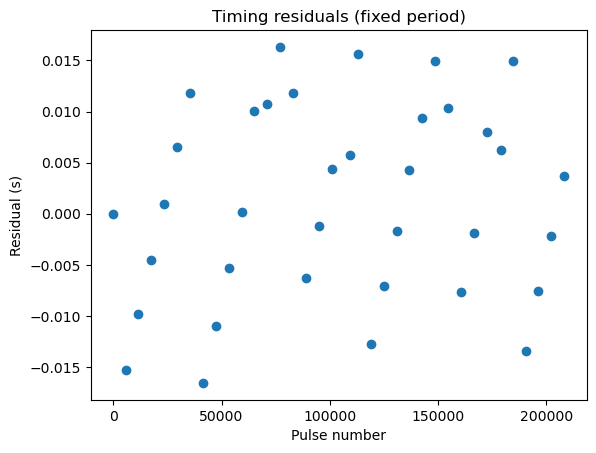

Slope: 2.5103282712278228e-08 seconds per pulse
Corrected period: 0.03385141510328271


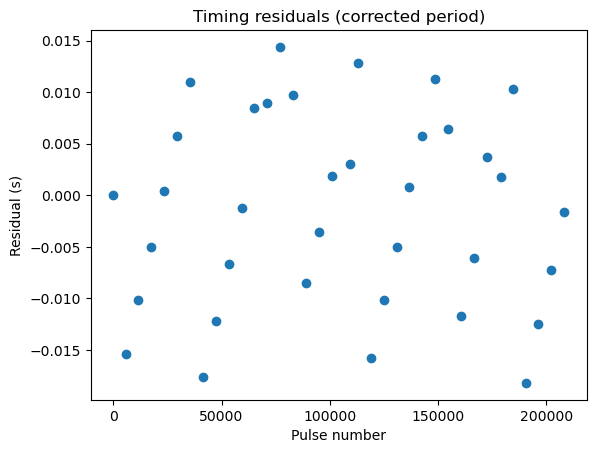

In [21]:
times_ec = times_mjd + earth_delay_sec / 86400
times_bary = times_ec + roemer_delay_sec / 86400

period_guess = float(obs["approx_period"])
print("Initial period guess:", period_guess)
t_sec = (times_bary - times_bary[0]) * 86400.0

pulse_number = np.round(t_sec / period_guess).astype(int)


t_model = pulse_number * period_guess
residuals = t_sec - t_model

import matplotlib.pyplot as plt

plt.figure()
plt.plot(pulse_number, residuals, "o")
plt.xlabel("Pulse number")
plt.ylabel("Residual (s)")
plt.title("Timing residuals (fixed period)")
plt.show()

coeff = np.polyfit(pulse_number, residuals, 1)
slope, intercept = coeff

print("Slope:", slope, "seconds per pulse")

period_corrected = period_guess + slope
print("Corrected period:", period_corrected)

t_model2 = pulse_number * period_corrected
residuals2 = t_sec - t_model2

plt.figure()
plt.plot(pulse_number, residuals2, "o")
plt.xlabel("Pulse number")
plt.ylabel("Residual (s)")
plt.title("Timing residuals (corrected period)")
plt.show()